In [1]:
import numpy as np 
import pandas as pd 
import os
import torch
from torch.utils.data import Dataset, DataLoader
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import random_split
from torchvision import transforms


In [2]:
class CornerDataset(Dataset):
    def __init__(self, annotations, image_dir):
        with open(annotations, 'r') as f:
            data = json.load(f)
            all_image_annotations = data["images"]
            corners_list = data["annotations"]["corners"]
        
        self.image_dir = image_dir
        self.corners_annotations = {
            corner['image_id']: corner['corners'] for corner in corners_list
        }
        
        self.image_annotations = []
        for item in all_image_annotations:
            img_path = os.path.join(image_dir, item["path"])
            if os.path.isfile(img_path) and item["id"] in self.corners_annotations:
                self.image_annotations.append(item)

        self.transform = transforms.Compose([
            transforms.Resize((112, 112)),  
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_annotations)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_annotations[idx]['path'])
        image = Image.open(img_path).convert("RGB")
        original_width, original_height = image.size
        image = self.transform(image)  
        
        img_id = self.image_annotations[idx]['id']
    
        corners_dict = self.corners_annotations[img_id]
        ordered_keys = ['top_left', 'top_right', 'bottom_right', 'bottom_left']
        corners = [corners_dict[key] for key in ordered_keys]
    
        normalized_corners = [
            [x / original_width, y / original_height] for (x, y) in corners
        ]
    
        flattened_corners = [coord for point in normalized_corners for coord in point]
    
        return image, torch.tensor(flattened_corners, dtype=torch.float32)



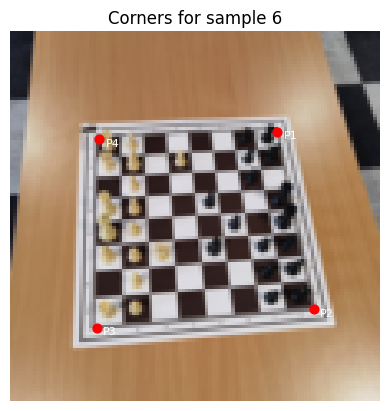

In [3]:
dataset = CornerDataset("/kaggle/input/dataset/dataset/annotations.json", "/kaggle/input/dataset/dataset/chessred2k/")
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 16

train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=lambda x: x, num_workers=4, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size, collate_fn=lambda x: x, num_workers=4, pin_memory=True)

def visualize_sample(dataset, index=0, image_size= 112):
    image, corners = dataset[index]
    
    if isinstance(image, torch.Tensor):
        image = transforms.ToPILImage()(image)

    plt.imshow(image)
    corners = corners.reshape(4, 2) * image_size
    plt.scatter(corners[:, 0], corners[:, 1], c='red', s=40)
    for i, (x, y) in enumerate(corners):
        plt.text(x + 2, y + 2, f"P{i+1}", color='white', fontsize=8)
    plt.title(f"Corners for sample {index}")
    plt.axis('off')
    plt.show()

visualize_sample(dataset, index=6)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet18(weights='DEFAULT')
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 8)
)
model.to(device)

def mean_point_error(preds, targets, image_size=112):
    preds_points = preds.view(preds.size(0), 4, 2) * image_size
    targets_points = targets.view(targets.size(0), 4, 2) * image_size

    per_point_errors = torch.sqrt(((preds_points - targets_points) ** 2).sum(dim=2)) 
    return per_point_errors.mean().item()


Using device: cuda


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


In [5]:
def one_epoch(model, optimizer, dataloader, loss_fn, is_training):
    model.train() if is_training else model.eval()
    avg_loss = 0.0
    avg_mpe = 0.0

    for batch in dataloader:
        images = torch.stack([b[0] for b in batch]).to(device)
        targets = torch.stack([b[1] for b in batch]).to(device)

        with torch.set_grad_enabled(is_training):
            preds = model(images)
            loss = loss_fn(preds, targets.view(preds.size(0), -1))
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        avg_loss += loss.item() / len(dataloader)
        avg_mpe += mean_point_error(preds, targets) / len(dataloader)

    return avg_loss, avg_mpe

In [6]:
import copy 

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
loss_fn = nn.MSELoss()

epochs = 150
patience = 5
best_val_metric = float('inf')
best_epoch = 0

for epoch in range(epochs):
    train_loss, train_mpe = one_epoch(model, optimizer, train_dataloader, loss_fn, True)
    val_loss, val_mpe = one_epoch(model, optimizer, val_dataloader, loss_fn, False)

    print(f"[Head Training] Epoch {epoch+1}: Train Loss = {train_loss:.4f}, MPE = {train_mpe:.4f} | Val Loss = {val_loss:.4f}, MPE = {val_mpe:.4f}")

    if val_mpe < best_val_metric:
        best_val_metric = val_mpe
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    elif epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation MPE: {best_val_metric:.4f}")
        break

model.load_state_dict(best_model_state)

for param in model.parameters():
    param.requires_grad = True

[Head Training] Epoch 1: Train Loss = 0.0654, MPE = 37.7208 | Val Loss = 0.0549, MPE = 35.1421
[Head Training] Epoch 2: Train Loss = 0.0487, MPE = 32.2169 | Val Loss = 0.0477, MPE = 31.4652
[Head Training] Epoch 3: Train Loss = 0.0418, MPE = 28.9781 | Val Loss = 0.0462, MPE = 30.4744
[Head Training] Epoch 4: Train Loss = 0.0409, MPE = 28.3608 | Val Loss = 0.0464, MPE = 31.0314
[Head Training] Epoch 5: Train Loss = 0.0359, MPE = 26.3843 | Val Loss = 0.0435, MPE = 29.1128
[Head Training] Epoch 6: Train Loss = 0.0351, MPE = 25.6712 | Val Loss = 0.0546, MPE = 31.9604
[Head Training] Epoch 7: Train Loss = 0.0319, MPE = 24.4217 | Val Loss = 0.0386, MPE = 26.2479
[Head Training] Epoch 8: Train Loss = 0.0289, MPE = 22.6816 | Val Loss = 0.0403, MPE = 26.5973
[Head Training] Epoch 9: Train Loss = 0.0267, MPE = 21.5041 | Val Loss = 0.0392, MPE = 26.2707
[Head Training] Epoch 10: Train Loss = 0.0266, MPE = 21.4134 | Val Loss = 0.0429, MPE = 27.1058
[Head Training] Epoch 11: Train Loss = 0.0236, MP

In [7]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

In [8]:
import copy

epochs = 150
patience = 5
best_val_metric = float('inf')
best_epoch = 0
train_history = {'loss': [], 'metric': []}
val_history = {'loss': [], 'metric': []}

for epoch in range(epochs):
    train_loss, train_mpe = one_epoch(model, optimizer, train_dataloader, loss_fn, True)
    train_history['loss'].append(train_loss)
    train_history['metric'].append(train_mpe)

    val_loss, val_mpe = one_epoch(model, optimizer, val_dataloader, loss_fn, False)
    val_history['loss'].append(val_loss)
    val_history['metric'].append(val_mpe)

    print(f"Epoch {epoch+1:3d}/{epochs} - Train Loss: {train_loss:.4f}, MPE: {train_mpe:.4f} | Val Loss: {val_loss:.4f}, MPE: {val_mpe:.4f}")

    # Early stopping
    if val_mpe < best_val_metric:
        best_val_metric = val_mpe
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    elif epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation MPE: {best_val_metric:.4f}")
        break

model.load_state_dict(best_model_state)

Epoch   1/150 - Train Loss: 0.0185, MPE: 14.7241 | Val Loss: 0.0130, MPE: 12.2110
Epoch   2/150 - Train Loss: 0.0090, MPE: 10.2619 | Val Loss: 0.0079, MPE: 9.6541
Epoch   3/150 - Train Loss: 0.0058, MPE: 8.2842 | Val Loss: 0.0054, MPE: 8.2449
Epoch   4/150 - Train Loss: 0.0033, MPE: 6.7526 | Val Loss: 0.0042, MPE: 6.9955
Epoch   5/150 - Train Loss: 0.0028, MPE: 6.1623 | Val Loss: 0.0060, MPE: 7.5923
Epoch   6/150 - Train Loss: 0.0019, MPE: 5.4785 | Val Loss: 0.0024, MPE: 5.7970
Epoch   7/150 - Train Loss: 0.0046, MPE: 6.7511 | Val Loss: 0.0046, MPE: 7.2277
Epoch   8/150 - Train Loss: 0.0042, MPE: 6.9837 | Val Loss: 0.0041, MPE: 6.6804
Epoch   9/150 - Train Loss: 0.0037, MPE: 6.3998 | Val Loss: 0.0040, MPE: 6.4810
Epoch  10/150 - Train Loss: 0.0018, MPE: 5.2764 | Val Loss: 0.0017, MPE: 5.1745
Epoch  11/150 - Train Loss: 0.0014, MPE: 4.7481 | Val Loss: 0.0030, MPE: 5.4634
Epoch  12/150 - Train Loss: 0.0017, MPE: 4.8146 | Val Loss: 0.0030, MPE: 5.2518
Epoch  13/150 - Train Loss: 0.0009, M

<All keys matched successfully>

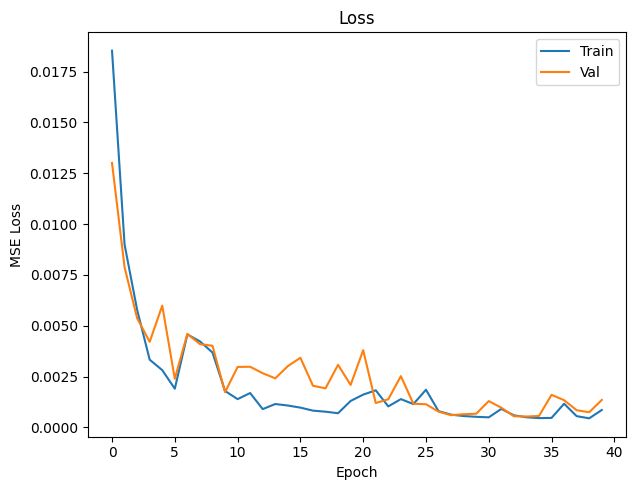

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_history['loss'], label='Train')
plt.plot(val_history['loss'], label='Val')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.tight_layout()
plt.show()

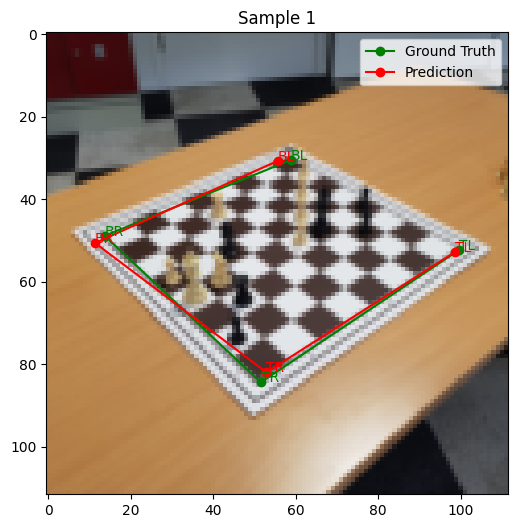

The corners are  [[99.657036 52.226665]
 [51.530743 84.37296 ]
 [13.694075 48.834816]
 [58.8137   30.477036]]
The predicted corners are  tensor([[98.6285, 52.7675],
        [52.9238, 81.9425],
        [11.3807, 50.5924],
        [55.6815, 30.6643]])


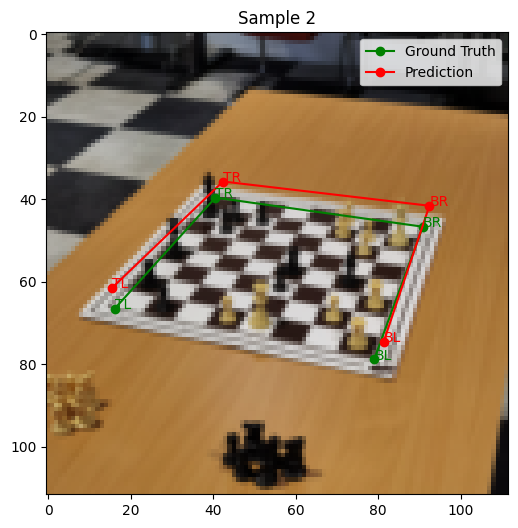

The corners are  [[16.12078  66.50365 ]
 [40.542397 39.57479 ]
 [90.817345 46.634583]
 [79.02198  78.819275]]
The predicted corners are  tensor([[15.5320, 61.4214],
        [42.3761, 35.6755],
        [92.4195, 41.5543],
        [81.3286, 74.5023]])


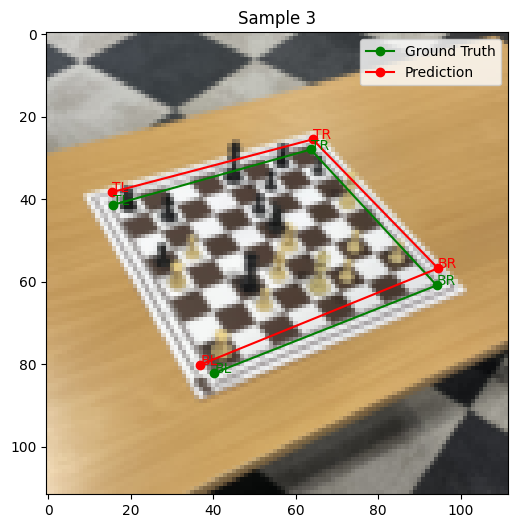

The corners are  [[15.821482 41.306297]
 [63.648148 27.914814]
 [94.19333  60.852592]
 [40.284813 82.10333 ]]
The predicted corners are  tensor([[15.4291, 38.2680],
        [64.1204, 25.4658],
        [94.4988, 56.7127],
        [36.8537, 80.1030]])


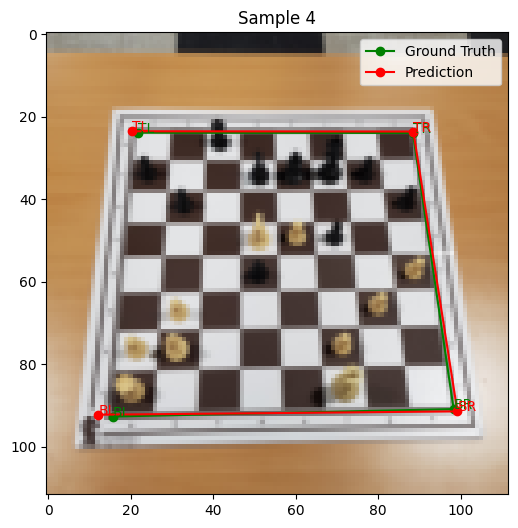

The corners are  [[21.744074 23.854074]
 [88.41481  23.905926]
 [98.30148  90.847404]
 [15.702963 92.65296 ]]
The predicted corners are  tensor([[20.4298, 23.4978],
        [88.5369, 23.5619],
        [99.2073, 91.4039],
        [12.1251, 92.2127]])


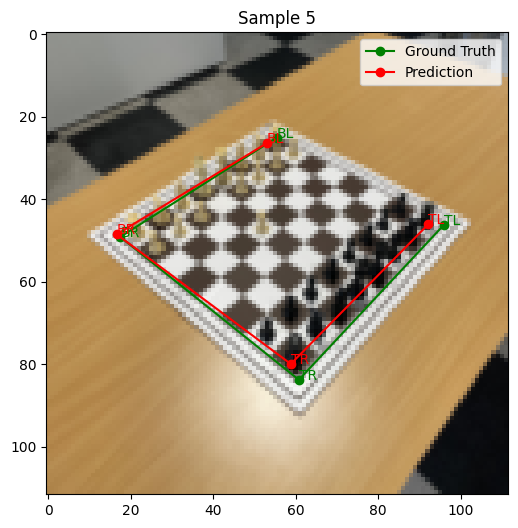

The corners are  [[95.92815  46.197037]
 [60.77778  83.74704 ]
 [17.471481 49.11593 ]
 [55.36741  25.065186]]
The predicted corners are  tensor([[92.1720, 46.0251],
        [58.8191, 79.9135],
        [16.6029, 48.4788],
        [52.9640, 26.4190]])


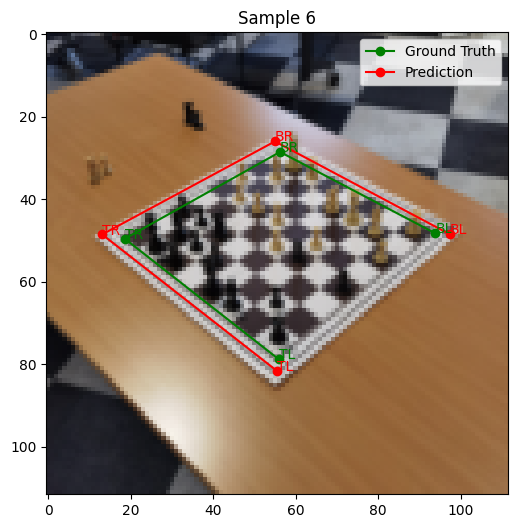

The corners are  [[55.856354 78.736145]
 [18.578438 49.549427]
 [56.215103 28.510416]
 [93.88277  48.24531 ]]
The predicted corners are  tensor([[55.3779, 81.5250],
        [13.0822, 48.5123],
        [54.9736, 25.9530],
        [97.3703, 48.4705]])


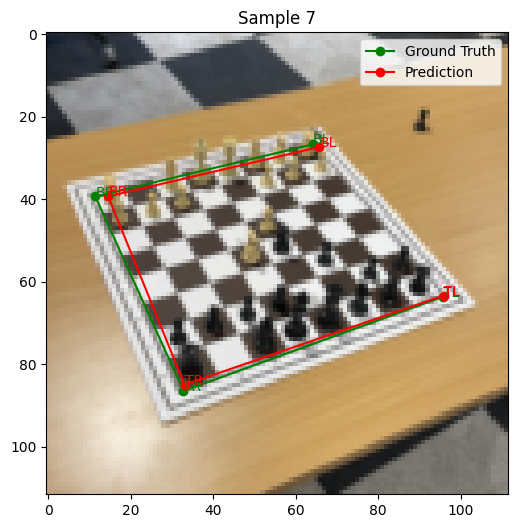

The corners are  [[95.82852  63.578518]
 [32.807037 86.44666 ]
 [11.432592 39.29926 ]
 [64.13481  26.671852]]
The predicted corners are  tensor([[95.8486, 63.3308],
        [33.0622, 84.9599],
        [14.5505, 39.2755],
        [65.7060, 27.3183]])


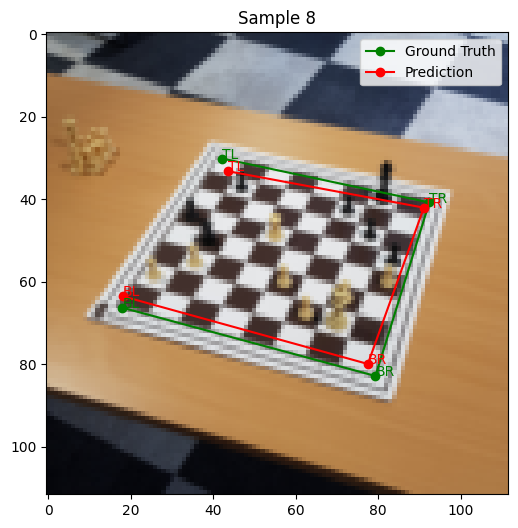

The corners are  [[42.252594 30.116297]
 [92.403336 40.76111 ]
 [79.3337   82.81815 ]
 [17.995926 66.270744]]
The predicted corners are  tensor([[43.4816, 33.1614],
        [91.0793, 42.0205],
        [77.5005, 79.9078],
        [18.1645, 63.5221]])


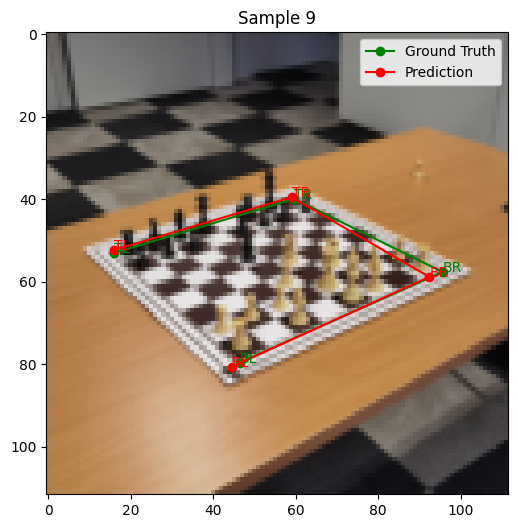

The corners are  [[15.871407 53.027554]
 [59.67573  39.883595]
 [95.62839  57.611458]
 [46.48656  79.557915]]
The predicted corners are  tensor([[16.0362, 52.2680],
        [59.0349, 39.4604],
        [92.4328, 58.8060],
        [44.4742, 80.6161]])


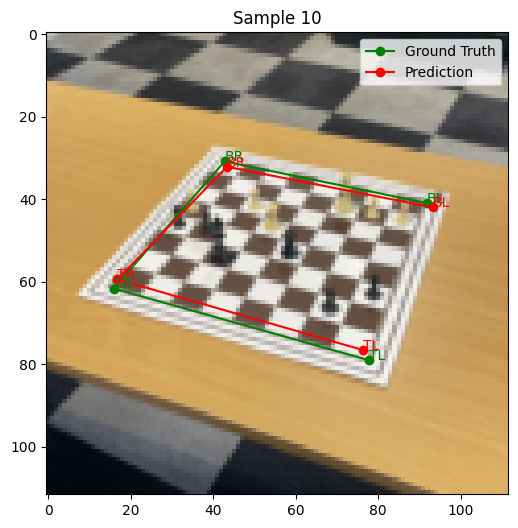

The corners are  [[77.67815  78.971855]
 [15.843333 61.614815]
 [42.774815 30.810371]
 [91.736664 40.89    ]]
The predicted corners are  tensor([[76.2569, 76.5166],
        [16.8051, 59.4121],
        [43.3540, 32.1012],
        [93.2421, 41.9574]])


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_predictions(model, dataset, num_samples=5, image_size=112):
    model.eval()
    
    for i in range(num_samples):
        image, gt_corners = dataset[i]
        input_image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_corners = model(input_image).cpu().view(-1, 2) * image_size

        image_np = image.permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, figsize=(6, 6))
        ax.imshow(image_np)

        gt_corners_np = gt_corners.numpy().reshape(-1, 2) * image_size
        ax.plot(gt_corners_np[:, 0], gt_corners_np[:, 1], 'go-', label='Ground Truth')
        ax.plot(pred_corners[:, 0], pred_corners[:, 1], 'ro-', label='Prediction')

        for j, txt in enumerate(['TL', 'TR', 'BR', 'BL']):
            ax.annotate(txt, (gt_corners_np[j][0], gt_corners_np[j][1]), color='green')
            ax.annotate(txt, (pred_corners[j][0], pred_corners[j][1]), color='red')

        ax.legend()
        ax.set_title(f"Sample {i+1}")
        plt.show()
        print("The corners are " , gt_corners_np)
        print("The predicted corners are " , pred_corners)

visualize_predictions(model, val_dataloader.dataset, num_samples=10)
